In [5]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import statsmodels.formula.api as smf
from plotnine import *
from sklearn.metrics import roc_curve, roc_auc_score

## Section 01 - Logistic regression on the Diabetes dataset
In this section we are considering the dataset pima-indians-diabetes.csv which is originally from
the National Institute of Diabetes and Digestive and Kidney Diseases. The objective of the dataset is
to diagnostically predict whether or not a patient has diabetes, based on certain diagnostic measurements included in the dataset. A more detailed description of the data can be obtained from Kaggle:
https://www.kaggle.com/uciml/pima-indians-diabetes-database. For this dataset, the outcome is 0 or 1.

In [7]:
diabetes = pd.read_csv("pima-indians-diabetes.csv")
# store feature columns for later
feature_columns = [c for c in diabetes.columns if c != "Outcome"]
diabetes.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


1. How balanced are the classes of the diabetes dataset?
2. Create an appropriate plot to visualize the relationship between the Outcome variable and the feature
variables Glucose, BloodPressure and Insulin. What do you conclude from your visualization?
3. Fit a logistic regression model for predicting Outcome only based on the feature Glucose. Inspect the
coefficients of the model’s predictors. According to the model, how much do the odds of getting diabetes
increase upon increasing the blood glucose level by 1 mg/dL?
4. Calculate the log-odds using the model from above for all samples in the dataset. Store the scores in a
new column of the dataset. Visualize the distributions of the scores with an appropriate plot. Which
type of distribution would you ideally expect?
Hint: Use the predict(linear=True) function.

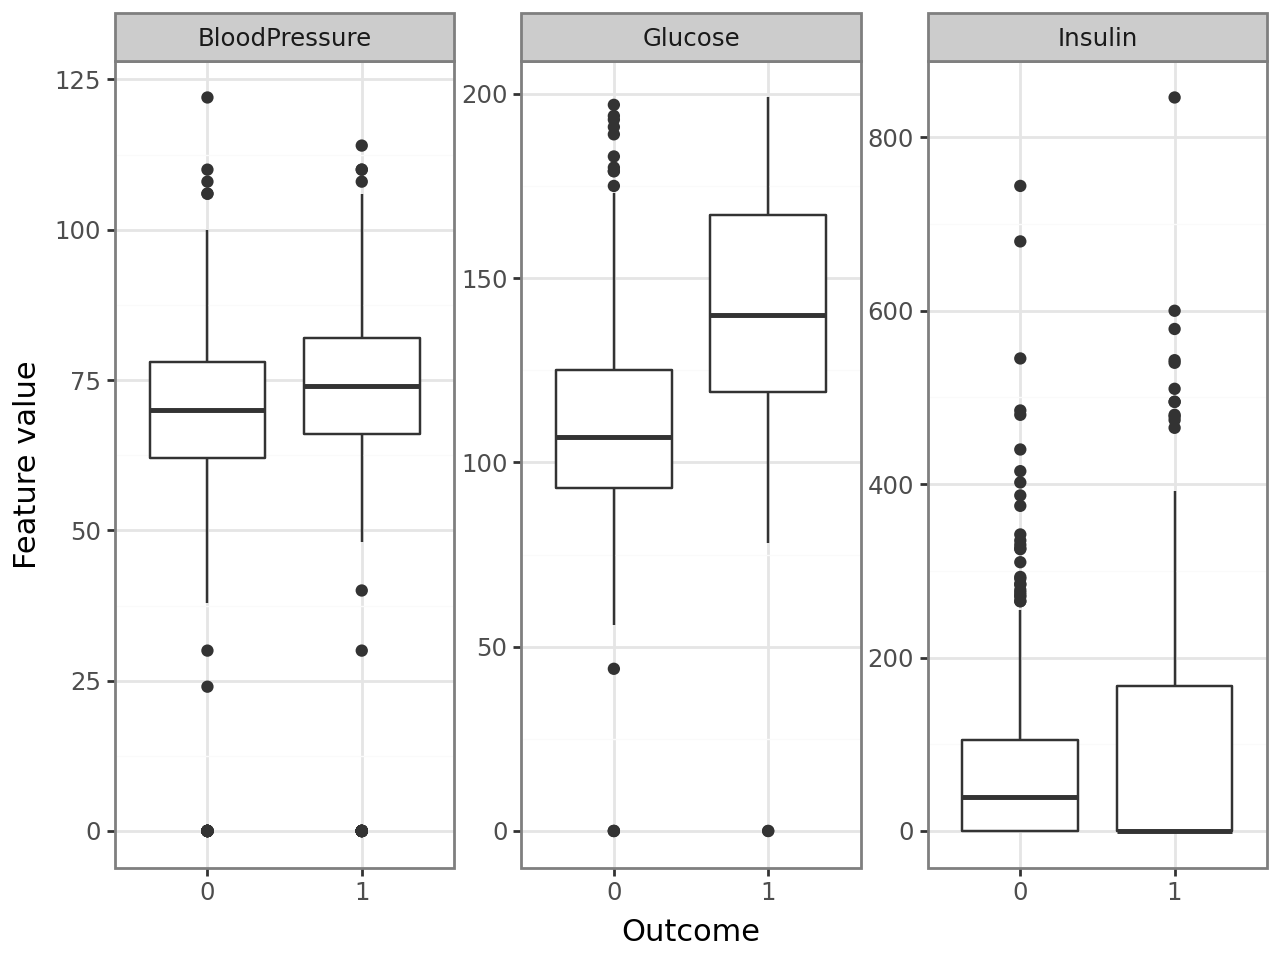

In [21]:
diabetes_df = diabetes[diabetes['Outcome'] == 1] # 1.
nodiabetes_df = diabetes[diabetes['Outcome'] == 0]

print("diabetes: " + str(diabetes_df['Glucose'].count()) + " no diabetes: " + str(nodiabetes_df['Glucose'].count()))

plot_df = diabetes[['Glucose', 'Outcome', 'BloodPressure', 'Insulin']].copy() # 2.
plot_df["Outcome"] = plot_df["Outcome"].astype(str)
melted = plot_df.melt(id_vars="Outcome", var_name="feature", value_name="value")

(ggplot(melted, aes("Outcome", "value"))
+ geom_boxplot()
+ facet_wrap("~feature", scales="free")
+ labs(x="Outcome", y="Feature value")
+ theme_bw()
) # Glucose has the highest separation between the two classes

In [25]:
logistic_fit = smf.glm("Outcome ~ Glucose", data=diabetes,
                       family=sm.families.Binomial()).fit() # 3.
diabetes["Prediction"] = logistic_fit.predict(diabetes)

diabetes.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome,Prediction
0,6,148,72,35,0,33.6,0.627,50,1,0.563439
1,1,85,66,29,0,26.6,0.351,31,0,0.106132
2,8,183,64,0,0,23.3,0.672,32,1,0.829302
3,1,89,66,23,94,28.1,0.167,21,0,0.121385
4,0,137,40,35,168,43.1,2.288,33,1,0.459719


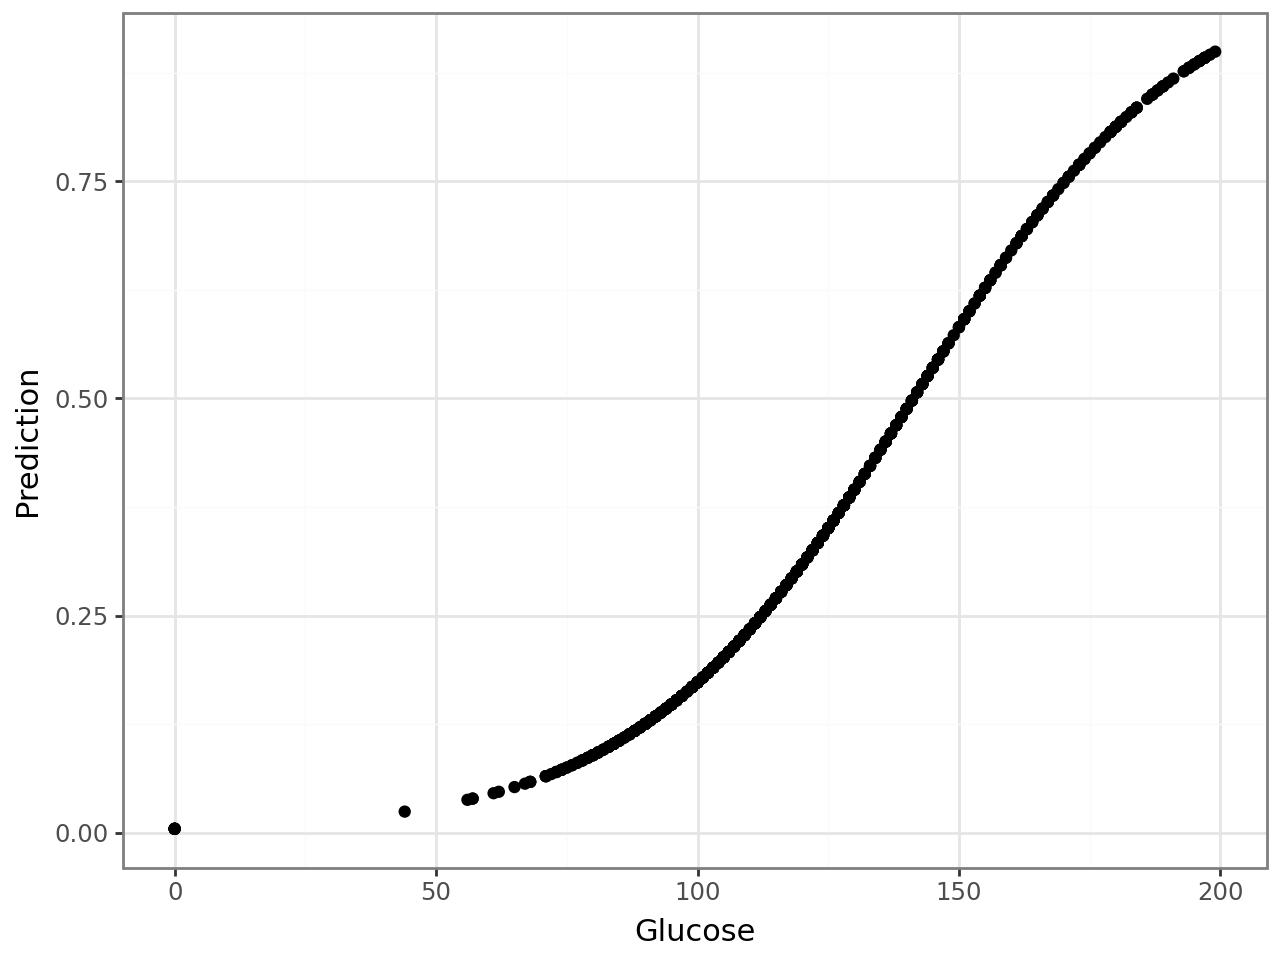

In [28]:
(ggplot(diabetes, aes("Glucose", "Prediction"))
+ geom_point()
+ labs(x="Glucose", y="Prediction")
+ theme_bw())

In [29]:
logistic_fit.params # the increase in odds for the increase in glucose is 3.8% per 1 mg/dL

Intercept   -5.350080
Glucose      0.037873
dtype: float64

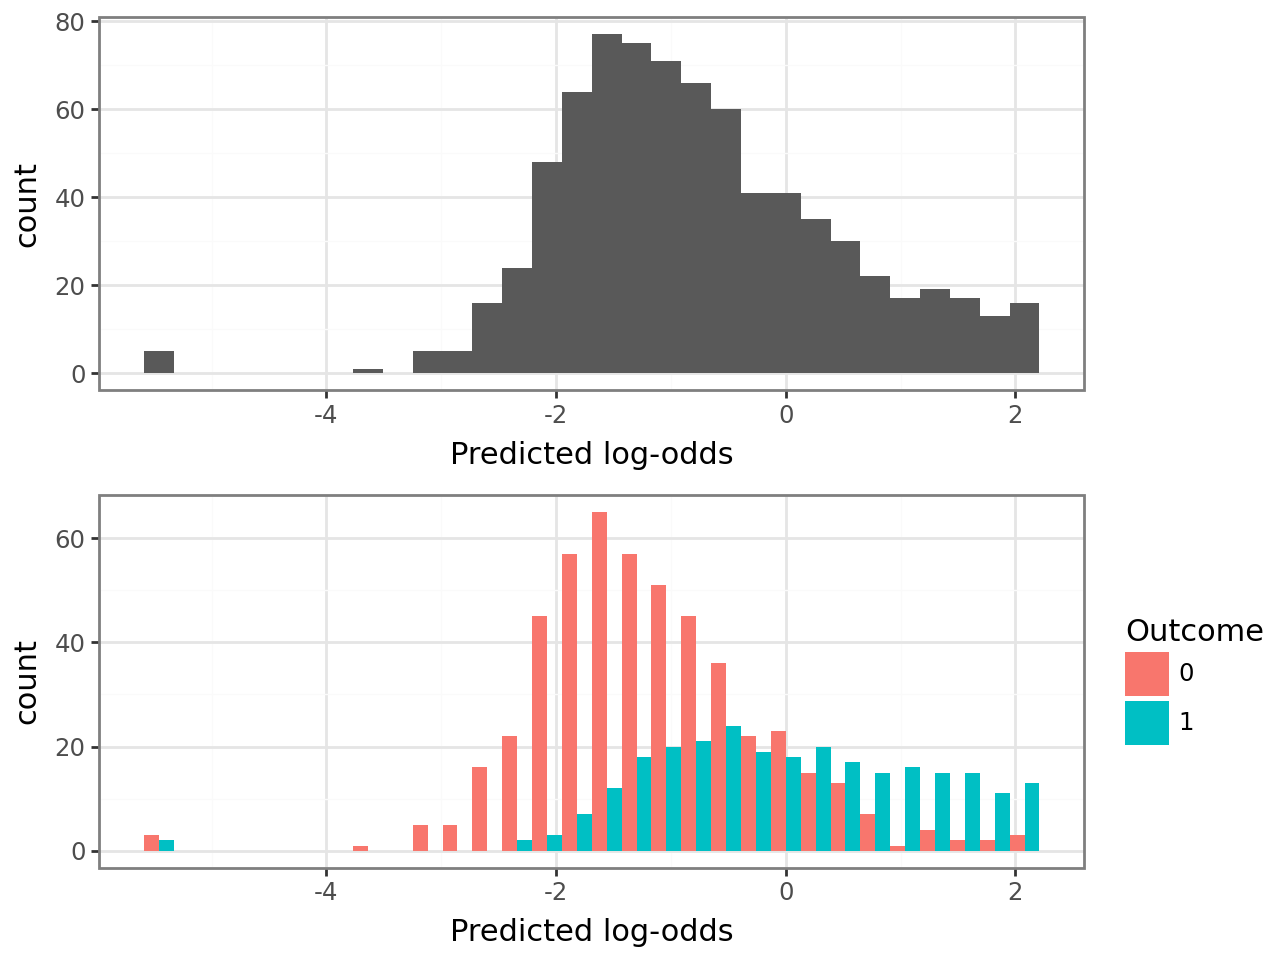

In [31]:
diabetes = diabetes.copy()
diabetes["score_glucose"] = logistic_fit.predict(diabetes, linear=True)
plot_df = diabetes.copy()
plot_df["Outcome"] = plot_df["Outcome"].astype(str)
p1 = (ggplot(plot_df, aes("score_glucose"))
+ geom_histogram(bins=30)
+ labs(x="Predicted log-odds")
+ theme_bw()
)
p2 = (ggplot(plot_df, aes("score_glucose", fill="Outcome"))
+ geom_histogram(position="dodge", bins=30)
+ labs(x="Predicted log-odds")
+ theme_bw()
)
p1 / p2

5. Create a function for computing the confusion matrix based on the predicted scores of a model and
the actual outcome. The function takes as input a threshold, a data table, the name of a scores column
and the name of a column with the actual labels. Then, compute the confusion matrix of the model for
the thresholds -1, 0 and 1. Are there any differences? What is the amount of false positives for the last
cutoff?

In [38]:
def confusion_matrix(df: pd.DataFrame, score_column: str,
                     labels_column: str,
                     threshold: float) -> pd.DataFrame:
    labels = df[labels_column].astype(int)
    pred_pos = (df[score_column] > threshold).astype(int)
    cm = pd.crosstab(labels, pred_pos)
    cm.index = ["actual_0", "actual_1"]
    cm.columns = ["pred_0", "pred_1"]
    return cm
thresholds = [-1, 0, 1]
for t in thresholds:
    print("Threshold =", t)
    print(confusion_matrix(diabetes, "score_glucose", "Outcome", t))
    print('<-|--|->' + '\n')

false_positive_last = confusion_matrix(diabetes, "score_glucose", "Outcome", 1).loc[
    "actual_0", "pred_1"
]

print({"false_positives_threshold_1": int(false_positive_last)})

Threshold = -1
          pred_0  pred_1
actual_0     308     192
actual_1      55     213
<-|--|->

Threshold = 0
          pred_0  pred_1
actual_0     443      57
actual_1     138     130
<-|--|->

Threshold = 1
          pred_0  pred_1
actual_0     489      11
actual_1     203      65
<-|--|->

{'false_positives_threshold_1': 11}


6. Create a second function for computing the TPR and FPR for a certain threshold, given predicted
scores and actual outcomes. What are TPR and FPR of the first model for thresholds -1, 0 and 1? Plot
these values in a scatter plot.

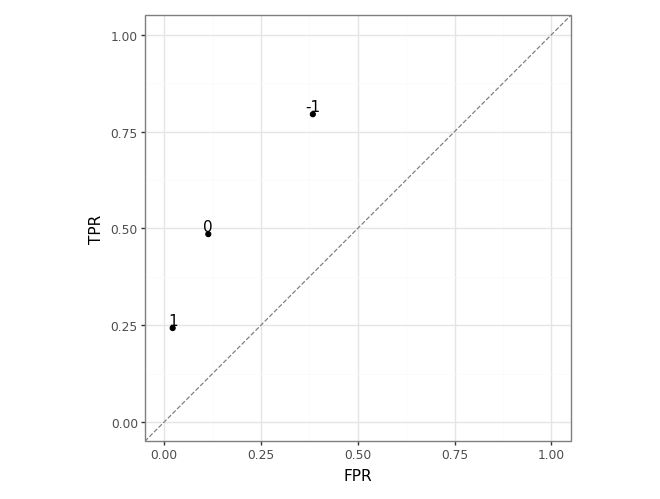

In [39]:
def tpr_fpr(df: pd.DataFrame, score_column: str,
            labels_column: str, threshold: float) -> pd.DataFrame:
    cm = confusion_matrix(df, score_column, labels_column, threshold)
    tp = cm.loc["actual_1", "pred_1"]
    fp = cm.loc["actual_0", "pred_1"]
    tn = cm.loc["actual_0", "pred_0"]
    fn = cm.loc["actual_1", "pred_0"]
    tpr = tp / (tp + fn) if (tp + fn) else np.nan
    fpr = fp / (fp + tn) if (fp + tn) else np.nan
    return pd.DataFrame({"tpr": [tpr], "fpr": [fpr], "t": [threshold]})
thresholds = [-1, 0, 1]
resulting_tpr_fpr = []

for t in thresholds:
    resulting_tpr_fpr.append(
    tpr_fpr(diabetes, "score_glucose", "Outcome", t))
dt = pd.concat(resulting_tpr_fpr, ignore_index=True)

(ggplot(dt, aes("fpr", "tpr", label="t"))
    + geom_point()
    + geom_text(nudge_y=0.02)
    + geom_abline(linetype="dashed", color="gray")
    + coord_equal()
    + xlim(0, 1)
    + ylim(0, 1)
    + labs(x="FPR", y="TPR")
    + theme_bw()
).draw()